## exercício 1
Considerando a base de dados vertebralcolumn-2C.csv, encontre o melhor
classificador dentre os métodos classificador Bayesiano, classificador Bayesino não-paramétrico e Naive Bayes.

In [78]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import accuracy_score
from scipy.stats import multivariate_normal

In [79]:
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))
    
def fit_likelyhood(Z, dist=gaussian):
    m =[]
    s=[]
    for j in np.arange(0, Z.shape[1]):
        m.append(np.mean(Z[:,j]))
        s.append(np.std(Z[:,j]))  
    def density(x, m=m, s=s):
        prob = 1
        for j in range(len(x)):
            prob = prob*dist(x[j], m[j], s[j])
        return prob
    return density

In [80]:
def calcula_probs(x_test, x_train, y_train, classes, classifier, h=2):
    P = pd.DataFrame(data=np.zeros((x_test.shape[0], len(classes))), columns = classes) 
    Pc = np.zeros(len(classes)) # Armaze a fracao de elementos em cada classe
    
    for i in np.arange(0, len(classes)): # Para cada classe
        elements = tuple(np.where(y_train == classes[i])) # elmentos na classe i
        Pc[i] = len(elements)/len(y_train) # Probabilidade pertencer a classe i
        Z = x_train[elements,:][0] # Elementos no conjunto de treinamento
        
        if classifier == 1: # bayes
            m = np.mean(Z, axis = 0)
            cv = np.cov(Z,rowvar=False)
            class_dist = multivariate_normal(mean=m, cov=cv, allow_singular=True).pdf
            
        if classifier == 2: # naive bayes
            class_dist = fit_likelyhood(Z)
            
        if classifier == 3: # bayes nao parametrico
            logclass_dist = KernelDensity(kernel='gaussian', bandwidth=h).fit(Z).score_samples
            class_dist = lambda x: np.exp(logclass_dist(np.array(x).reshape(1,len(x))))
            
        for j in np.arange(0,x_test.shape[0]): # para cada observacao no conjunto de teste
            x = list(x_test[j,:])
            # calcula a probabilidade pertencer a cada classe
            pj = class_dist(x)
            P[classes[i]][j] = pj*Pc[i]
    return P

In [81]:
def predicao(P):
    y_pred = [] # Vetor com as classes preditas
    for i in np.arange(0, P.shape[0]):
        c = np.argmax(np.array(P.iloc[[i]]))
        y_pred.append(classes[c])
    y_pred = np.array(y_pred, dtype=classes.dtype)
    return y_pred

In [82]:
#random.seed(42)
data = pd.read_csv('data/vertebralcolumn-2C.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)  

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Transforma os dados para terem media igual a zero e variancia igual a 1
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

In [93]:
# Seleciona os conjuntos de treinamento e teste
p = 0.8 # fraction of elements in the training set
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p)

In [94]:
P1 = calcula_probs(x_test, x_train, y_train, classes, classifier=1)
P2 = calcula_probs(x_test, x_train, y_train, classes, classifier=2)
P3 = calcula_probs(x_test, x_train, y_train, classes, classifier=3)
y_pred1 = predicao(P1)
y_pred2 = predicao(P2)
y_pred3 = predicao(P3)

In [98]:
# calcula a acuracia
score1 = accuracy_score(y_pred1, y_test)
print('Acuracia (bayseano):', score1)
score2 = accuracy_score(y_pred2, y_test)
print('Acuracia (naive):', score2)
score3 = accuracy_score(y_pred3, y_test)
print('Acuracia (bays nao parametrio):', score3)

Acuracia (bayseano): 0.7903225806451613
Acuracia (naive): 0.7258064516129032
Acuracia (bays nao parametrio): 0.5967741935483871


In [99]:
from sklearn.naive_bayes import GaussianNB # comparando com naive bayes da sklearn

model = GaussianNB()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print('Acuracia: ', model.score(x_test, y_test))

Accuracy:  0.7419354838709677


## exercício 2
Considerando a base de dados “winequality-red”, encontre o valor do hiperparâmetro
h que oferece a maior acurácia no Bayesino não-paramétrico.

In [9]:
#random.seed(42)
data = pd.read_csv('data/winequality-red.csv', header=(0))

classes = np.array(pd.unique(data[data.columns[-1]]), dtype='float64')  

# Converte para matriz e vetor do numpy
data = data.to_numpy()
nrow, ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# Transforma os dados para terem media igual a zero e variancia igual a 1
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

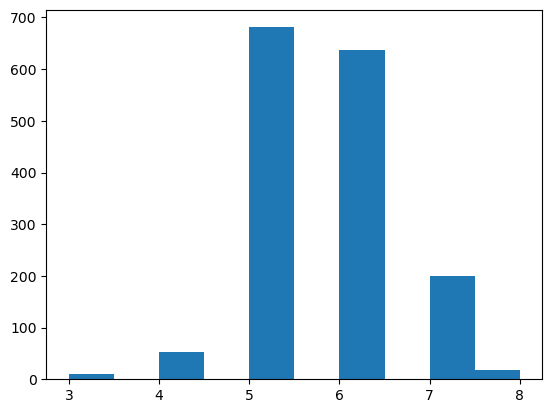

In [65]:
plt.hist(y)
plt.show()

In [69]:
hh = np.linspace(0.01,3,10)
n=5
score = np.empty([len(hh)*n,2])
c=0
for i in range(len(hh)):
    for j in range(n):
        p = 0.8 # fraction of elements in the training set
        x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = p)
        P = calcula_probs(x_test, x_train, y_train, classes, classifier=3,h=hh[i])
        score[c,1] = (accuracy_score(predicao(P), y_test))
        score[c,0] = hh[i]
        c+=1

acerto máximo =  0.61875 , h =  0.34222222222222226


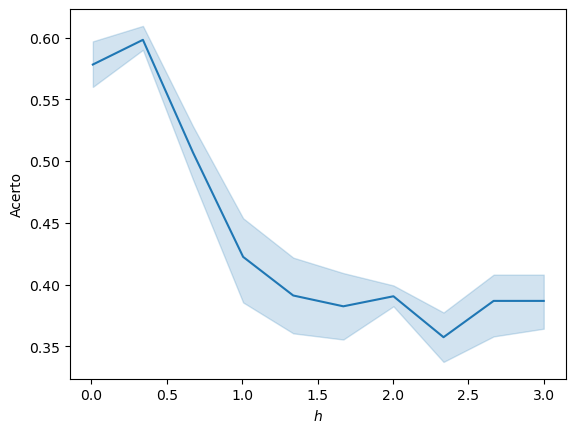

In [77]:
ax = sns.lineplot(x=score[:,0],y=score[:,1])
ax.set(xlabel="$h$",ylabel="Acerto")
print("acerto máximo = ",np.max(score[:,1]),", h = ", score[np.argmax(score[:,1]),0])